독립표본 티테스트

In [8]:
# 통계흐름

# 데이터 확인
# - 두 집단 각각 데이터 확인 (group1, group2)
# - std 확인

# 시각화와 같은 방법으로 분포 확인 (각 그룹 따로 + 비교)
# - histogram (group별)
# - boxplot (group 비교)
# - 크게 이상없으면 진행

# - 이상치 있으면 확인 후 처리 (무조건 제거 X)
#   → 측정 오류면 제거, 실제 값이면 유지

# - 너무 편향이 심하면 로그변환 또는 비모수 검정 고려
#   (약간 치우친 정도는 괜찮고, 이상치 없으면 보통 t-test 가능)
#   (표본개수 각 그룹 20개 이상이면 어느 정도 robust)

# 등분산성 확인 (독립표본 핵심)
# - Levene test로 두 그룹 분산 비교
# - 등분산이면 Student t-test
# - 등분산 아니면 Welch t-test 사용

# 신뢰구간 확인
# - 두 그룹 평균 차이의 신뢰구간 확인

# t-test
# - 독립표본 t-test 수행 (equal_var 여부 선택)

# 효과크기(effect size) 확인
# - Cohen's d 계산 (두 그룹 차이 크기 해석)

In [9]:
# 가정
# 그룹 A (30명): 평균 약 48 /그룹 B (30명): 평균 약 55
# 두 집단 평균이 다른지 검정

import numpy as np
import pandas as pd

# 사용자 체류시간 (분) - A그룹 (기존 UI 버전)
df_a = pd.DataFrame({
    "session_time": [
        5.5, 6.2, 4.8, 5.9, 6.5,
        5.1, 5.8, 6.0, 5.7, 6.3,
        5.4, 6.1, 5.6, 5.9, 6.2,
        5.3, 5.8, 6.4, 6.0, 5.7
    ],
    "group": "A"
})

# 사용자 체류시간 (분) - B그룹 (새로 비교 대상 생성)
df_b = pd.DataFrame({
    "session_time": [
        6.8, 7.1, 6.5, 7.3, 6.9,
        7.0, 6.7, 7.2, 6.6, 7.4,
        6.8, 7.1, 6.9, 7.0, 7.3,
        6.5, 7.2, 6.8, 7.1, 6.9
    ],
    "group": "B"
})

In [17]:
# 두 그룹의 분포 확인
# 원샘플티테스트에서는 std/mean을 통해 그 데이터 자체의 흔들림을 봤지만
# 독립표본에서는 비교군이 두 그룹이기때문에 각 그룹자체의 흔들림은 그닥 중요치 않음
# 독립표본에서는 std자체를 보고 각 그룹의 데이터 퍼짐정도를 확인하는 정도
# 독립표본에서는 등분산 여부확인이 더 중요

print('A그룹 std')
print(df_a.describe())

print()

print('B그룹 std')
print(df_b.describe())

A그룹 std
       session_time
count     20.000000
mean       5.810000
std        0.438778
min        4.800000
25%        5.575000
50%        5.850000
75%        6.125000
max        6.500000

B그룹 std
       session_time
count     20.000000
mean       6.955000
std        0.262528
min        6.500000
25%        6.800000
50%        6.950000
75%        7.125000
max        7.400000


In [11]:
# 두개의 그룹 합치기
# 무조건 합칠 필요는 없지만 시각화, 그룹비교 등을 위해
# 두 그룹의 데이터를 합쳐주는것이 좋음

total_df = pd.concat([df_a,df_b])
total_df

,session_time,group
0,5.5,A
1,6.2,A
2,4.8,A
3,5.9,A
4,6.5,A
5,5.1,A
6,5.8,A
7,6.0,A
8,5.7,A
9,6.3,A


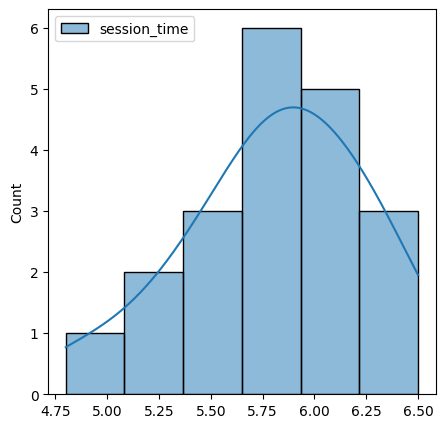

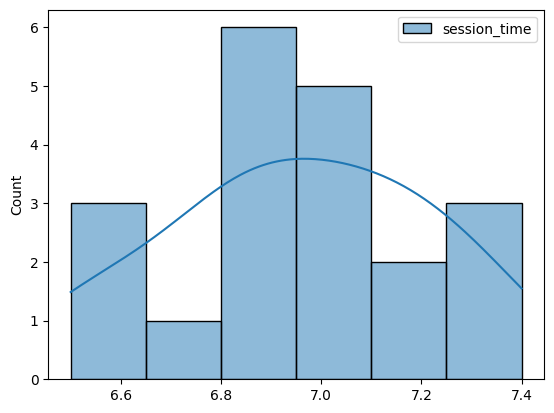

In [12]:
# 시각화_히스토그램

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(5,5))

#A그룹
sns.histplot(total_df[total_df['group']=='A'], kde = True)
plt.show()
sns.histplot(total_df[total_df['group']=='B'], kde = True)
plt.show()

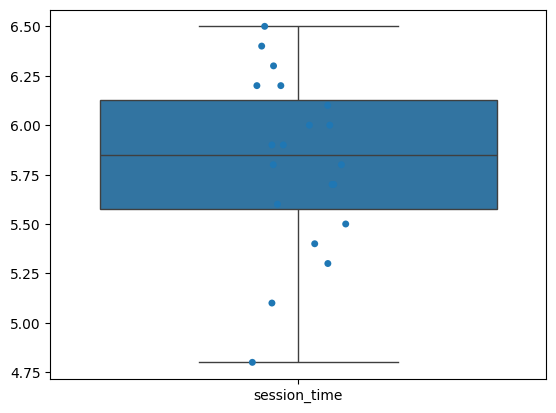

<Axes: >

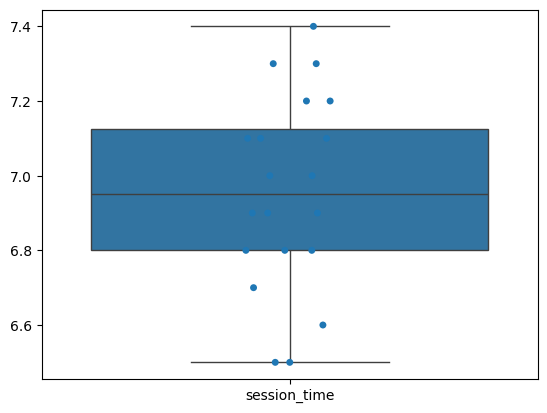

In [16]:
# 박스플롯_시각화

# 독립표본에서는 등분산성이 중요하기때문에
# 박스플롯을 통해 두 그룹의 분산이 다른지 같은지 대략적인 확인
# [확인해야 할것]
# 박스 높이 차이 (IQR)
# 수염 길이
# 퍼짐 정도
# 이 세가지가 어느정도 비슷하면 등분산인 상태

# 그래프 두개를 한꺼번에 확인가능
sns.boxplot(total_df[total_df['group']=='A'], showfliers = True)
sns.stripplot(total_df[total_df['group']=='A'])
plt.show()

# B그룹
sns.boxplot(total_df[total_df['group']=='B'],showfliers=True)
sns.stripplot(total_df[total_df['group']=='B'])

In [30]:
# 등분산성 수치 확인

from scipy import stats

a = total_df[total_df['group']=='A']['session_time']
b = total_df[total_df['group']=='B']['session_time']

# stat : 검정통계량(데이터가 가설에서 얼마나 벗어났는지 숫자로 표현한 값)
# 원샘플 티테스트도 그렇고 독립표본도 그렇고 검정통계량은 직접하지않고 p값을 주로 봄
# 검정통계량은 해석기준이 없고 데이터마다 스케일이 달라서 절대기준이 없음
# 또한 이미 p값이 stat을 기반으로 계산된 최종결과이기때문
stat, p_value = stats.levene(a,b)
print(f'검정통계량 : {stat}')
print(f'p-value : {p_value}') # 0.05보다 큼

# 귀무가설이 두 그룹의 등분산성이 같다고 가정했기때문에
# 0.05보다 높은 0.07이 나와서 귀무가설을 기각하지못함(등분산성이 같음)

검정통계량 : 3.366884037425581
p-value : 0.0743567188287528


In [37]:
# 신뢰구간 확인

from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

a_stats = DescrStatsW(a)
b_stats = DescrStatsW(b)

# CompareMeans : 두 집단의 평균을 비교하기 위한 도구
cm = CompareMeans(a_stats, b_stats)

# 신뢰구간 계산
ci_low, ci_high = cm.tconfint_diff()
print(ci_low, ci_high)
# 두 평균 차이의 신뢰구간은 -1.3 ~ -0.9사이에 존재할 확률이 높음

-1.3764580107034905 -0.9135419892965086


In [32]:
# 독립표본 t-test
# 두 그룹이 같다는 전제하에 평균을 비교하는 것
# 정규성과 등분산성이 어느정도 만족하기때문에 student t-test사용
# Student t-test : 두 평균의 차이 / 표준오

from scipy import stats

a = total_df[total_df['group']=='A']['session_time']
b = total_df[total_df['group']=='B']['session_time']

# equal_var = True : 분산이 같다는 가정이라고 알려주는것
t, p_value = stats.ttest_ind(a,b, equal_var=True)

# 독립표본에서의 t값 : (a평균 - b평균) / se
# 독립표본 t값 : 평균차이가 표준오차 몇배?
print(f'{t}') # 두 그룹 평균차이가 표준오차 기준으로 -10배 정도로 매우 크다
print(f'{p_value}') # 평균차이 있음

-10.014478698032997
3.2795096528227815e-12


In [35]:
# effect size확인
# 독립표본의 effect size의 std는 두 그룹의 표준편차를 합쳐서 만든 대표 표준편차를 사용함
# 원샘플의 경우 샘플이 1개이기때문에 그 데이터의 std를 사용했지만 독립표본은 두 그룹이기때문

# 대표 std만드는 공식 : pooled_std = sqrt((a그룹 std² + b그룹 std²) / 2)

import math

pooled_std = math.sqrt((a.std()**2 + b.std()**2) / 2)
print(f'd값 : {(a.mean() - b.mean()) / pooled_std}')
# 표준편차 기준으로 -3배차이

d값 : -3.166856226502187
